In [69]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                            accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [70]:
df = pd.read_csv('ml_dataset_50-50_14-10-2025.csv')

print(f"\nDataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['attack'].value_counts())
print(f"\nAttack ratio: {df['attack'].sum() / len(df) * 100:.2f}%")


Dataset shape: (3414, 69)

Class distribution:
attack
0    2656
1     758
Name: count, dtype: int64

Attack ratio: 22.20%


In [ ]:
X = df.drop(['timestamp', 'attack'], axis=1)
y = df['attack']

print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {list(X.columns)}")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training set attack ratio: {y_train.sum() / len(y_train) * 100:.2f}%")
print(f"Test set attack ratio: {y_test.sum() / len(y_test) * 100:.2f}%")

In [72]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
lr_model = LogisticRegression(
    penalty='l2',              # L2 regularization
    C=1.0,                     # Inverse of regularization strength
    solver='lbfgs',            # Optimization algorithm
    max_iter=1000,             # Maximum iterations
    random_state=42,
    n_jobs=-1,                 # Use all CPU cores
    class_weight='balanced',   # Handle class imbalance
    verbose=1
)

lr_model.fit(X_train_scaled, y_train)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1,
                   random_state=42, verbose=1)

In [74]:
# Predictions
y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

In [75]:
# Evaluate
print("Model evaluation:")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

print("Confusion matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

Model Evaluation:

Accuracy: 0.8741
Precision: 0.6650
Recall: 0.8750
F1-Score: 0.7557
ROC-AUC Score: 0.9041
Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.87      0.92       531
      Attack       0.67      0.88      0.76       152

    accuracy                           0.87       683
   macro avg       0.81      0.87      0.84       683
weighted avg       0.89      0.87      0.88       683

Confusion Matrix:
[[464  67]
 [ 19 133]]

True Negatives: 464
False Positives: 67
False Negatives: 19
True Positives: 133


In [76]:
print("Feature coefficient analysis:")
feature_coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_model.coef_[0],
    'abs_coefficient': np.abs(lr_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("\nTop 15 Most important features (by coefficient):")
print(feature_coefficients.head(15)[['feature', 'coefficient']].to_string(index=False))

Feature coefficient analysis

Top 15 Most important features (by coefficient):
                        feature  coefficient
            flow_byte_count_std    -1.623145
                no_of_udp_flows    -1.613141
               tcp_to_udp_ratio     1.304784
              no_of_total_flows    -0.957842
                no_of_tcp_flows    -0.954482
       port_tx_packets_10s_mean     0.940606
     flow_packet_count_10s_mean     0.892506
            port_tx_packets_std     0.719663
     no_of_unique_dst_addresses    -0.718641
         no_of_unique_src_ports     0.703550
unique_src_to_dst_address_ratio    -0.667808
       port_rx_packets_10s_mean    -0.626621
                total_flows_10s     0.611682
            flow_byte_count_sum     0.601548
     no_of_unique_src_addresses     0.530707


Text(0.5, 611.5833333333334, 'Predicted')

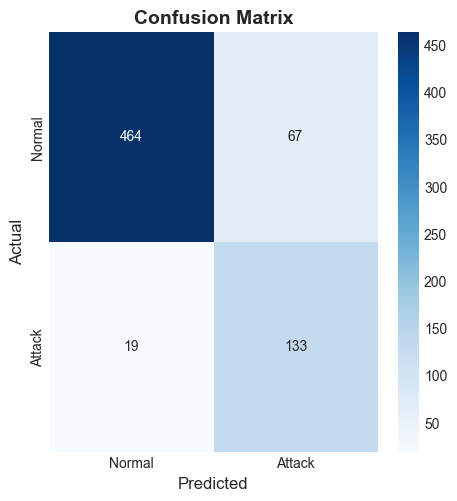

In [77]:
# Visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig = plt.figure(figsize=(18, 12))

# 1. Confusion Matrix Heatmap
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

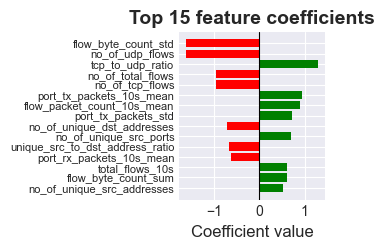

In [84]:
# 2. Feature coefficients (Top 15)
ax2 = plt.subplot(2, 3, 2)
top_features = feature_coefficients.head(15)
colors = ['red' if x < 0 else 'green' for x in top_features['coefficient']]
plt.barh(range(len(top_features)), top_features['coefficient'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'], fontsize=8)
plt.xlabel('Coefficient', fontsize=12)
plt.title('Top 15 features by coefficient', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.gca().invert_yaxis()

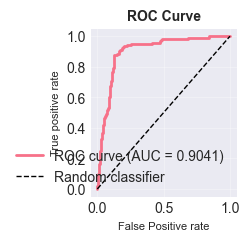

In [79]:
# 3. ROC Curve
ax3 = plt.subplot(2, 3, 3)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive rate', fontsize=8)
plt.ylabel('True positive rate', fontsize=8)
plt.title('ROC Curve', fontsize=10, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

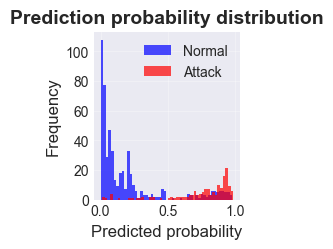

In [80]:
# 4. Prediction distribution
ax4 = plt.subplot(2, 3, 4)
plt.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.7, label='Normal', color='blue')
plt.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.7, label='Attack', color='red')
plt.xlabel('Predicted probability', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Prediction probability distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

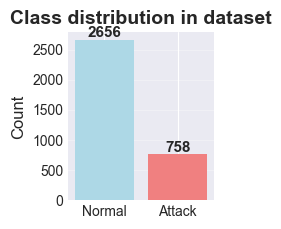

In [81]:
# 5. Class distribution
ax5 = plt.subplot(2, 3, 5)
class_counts = y.value_counts()
plt.bar(['Normal', 'Attack'], class_counts.values, color=['lightblue', 'lightcoral'])
plt.ylabel('Count', fontsize=12)
plt.title('Class distribution in dataset', fontsize=14, fontweight='bold')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

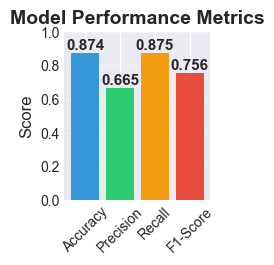

In [82]:
# 6. Model performance metrics
ax6 = plt.subplot(2, 3, 6)
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred)
}
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars = plt.bar(metrics.keys(), metrics.values(), color=colors)
plt.ylim(0, 1)
plt.ylabel('Score', fontsize=12)
plt.title('Model performance metrics', fontsize=14, fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

plt.show()

In [83]:
# Save the model and scaler
# import joblib
# joblib.dump(lr_model, 'lr_model.pkl')
# joblib.dump(scaler, 'scaler.pkl')
# print("Model saved as 'lr_model.pkl'")
# print("Scaler saved as 'scaler.pkl'")

feature_coefficients.to_csv('feature_coefficients.csv', index=False)